In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))
import CIBUSmod as cm

# Soil carbon and climate impact calculations
The code in this notebook calculates and manages C flows to and from soils as well as climate impacts.

In this section the `xarray` package is being heavily used for its excellent handling of multidimensional data.
It may take some time to get used to how to use it. For that reason, below is a cell with tips on how to learn using its functionalities.

For the functions and methods in the `SoilData` class to work the `xarray` package must be installed (pip install xarray)

## Run either Option 1 or Option 2 below

### Option 1: Create a new instance from a saved scenario

In [12]:
# To create a new 'SoilData' instance based on a session saved in 'run_scn' use:
FAI_new = cm.SoilData('session_FAI.csv', 'session_FAI_name')

Dataset set to ['input', 'soc', 'historic']
input_df saved as FAI_input_df in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
Saved instance variable states to /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results/FAI


### Option 2: Recreate a saved instance that was computed and saved previously

In [2]:
# To restore and continue working on a previously created instance of the 'SoilData' class set the name and parameters of the following function call to the scenario name (e.g. 'FAI'):
FAI = cm.SoilData.load_instance_state('FAI')
FAI.load_inventory()
#FAI_soil.save_inventory()
#FAI_soil.save_instance_state()

The following dataset variables have been set:
 input_inventory
The following dataframe variables have been set:
 input_df
 ss_input_df
The following dataset variables have been set:
 soc_inventory
The following dataframe variables have been set:
 soc_ha_df
 soc_sko_df
The following dataset variables have been set:
 historic_inventory
The following dataframe variables have been set:
 historic_ha_df
 historic_sko_df
No dataset variables have been loaded.
No dataframe variables have been loaded.


The following code block can be used to check which variables have currently been set.
Both public and private attributes are shown to facilitate quick troubleshooting. 

In [4]:
# 'private' functions are helper functions used to calculate the inventories and dataframes
# stored in the 'public'' variables. These are not saved and reloaded with the above commands
FAI.check_attributes_status('public'), FAI.check_attributes_status('private')

NameError: name 'FAI' is not defined

### To check if the imported variables were set as expected you can run:

In [3]:
scn_name = FAI_new
print(f'Name: {scn_name.name}')
print(f'Scenario: {scn_name.scenario}')
print(f'startyear: {scn_name.startyear}')
print(f'Index:\n{scn_name.input_df.index.dtypes}')
print(f'Columns:\n{scn_name.input_df.columns}')

Name: food_as_industry
Scenario: FAI
startyear: 2020
Index:
scn                    object
crop                   object
prod_system            object
region                  int64
input_year     datetime64[ns]
dtype: object
Columns:
Index(['area_ha', 'harvest_kgdm', 'crop_residues_harvest_kgdm',
       'manure_cattle_kgC', 'manure_horses_kgC', 'manure_pigs_kgC',
       'manure_poultry_kgC', 'manure_sheep_kgC'],
      dtype='object')


## Calculate the carbon inputs for each input fraction in the input_df
The `calc_scn_inputs` method calculates the C input for each fraction of `input_df` and sets the  following variable attributes:
- `startyear`: defined as the first year of the timeseries in `input_df`.
- `input_inventory`: xarray dataset with `scn, crop, prod_system, region, input_year` as coordinates, including all original input and the C input per ha as well as per SKO for all fractions.
- `ss_input_df.columns`: dataframe containing the SOC inputs to use for the spinup modelling, corresponding to the C inputs for all fraction in the `startyear`, also both per ha and per SKO. 

**Note:** the column or index level name `year` in the `input_df` will be renamed to `input_year` to distinguish it from other time coordinates calculated with ICBM and subsequent temperature response functions.

In [13]:
FAI_new.calc_scn_inputs(verbose=True, looped=False)

Calculating scenario inputs...
---Executing calc_scn_inputs()---
Warning, first index label is None, conversion of index label not possible
Warning, index label is None. No conversion of index values (should be auto-generated ints)
>>> Executing '_calc_input_ha()'<<<
>>> '_calc_input_ha()' executed succesfully <<<
input_df.columns now: Index(['scn', 'crop', 'prod_system', 'region', 'input_year', 'area_ha',
       'harvest_kgdm', 'crop_residues_kgdm', 'manure_cattle_kgc',
       'manure_horses_kgc', 'manure_pigs_kgc', 'manure_poultry_kgc',
       'manure_sheep_kgc', 'areayield', 'areayield_residues'],
      dtype='object')
>>> Executing '_calc_amnd_ha()'<<<
--- Inserted manure_cattle_ha---
--- Inserted manure_horses_ha---
--- Inserted manure_pigs_ha---
--- Inserted manure_poultry_ha---
--- Inserted manure_sheep_ha---
>>> '_calc_amnd_ha()' executed succesfully <<<
input_df.columns now: Index(['scn', 'crop', 'prod_system', 'region', 'input_year', 'area_ha',
       'harvest_kgdm', 'crop_re

In [11]:
FAI_new.input_df

,scn,crop,prod_system,region,input_year,area_ha,harvest_kgdm,crop_residues_kgdm,i_ag_manure_cattle_kgc,i_ag_manure_horses_kgc,...,i_ag_manure_cattle_ha,i_ag_manure_horses_ha,i_ag_manure_pigs_ha,i_ag_manure_poultry_ha,i_ag_manure_sheep_ha,i_ag_crop_ha,i_bg_crop_ha,alloc_source_crop,i_ag_crop_kgc,i_bg_crop_kgc
0,fai,"wheat, winter",conventional,1011,2020-01-01,3267.670519,2.096704e+07,1.046322e+07,153663.281260,6145.792790,...,47.025329,1.880787,127.530398,1113.313472,2.410221,NaN,NaN,none,NaN,NaN
1,fai,"wheat, winter",conventional,1011,2021-01-01,3246.324127,2.098767e+07,1.052935e+07,152685.689225,6093.668658,...,47.033409,1.877098,128.567276,1122.303435,2.478272,NaN,NaN,none,NaN,NaN
2,fai,"wheat, winter",conventional,1011,2022-01-01,3224.977736,2.100831e+07,1.059548e+07,151708.097190,6041.544525,...,47.041595,1.873360,129.617881,1131.412409,2.547223,NaN,NaN,none,NaN,NaN
3,fai,"wheat, winter",conventional,1011,2023-01-01,3203.631344,2.102894e+07,1.066162e+07,150730.505156,5989.420393,...,47.049891,1.869572,130.682487,1140.642772,2.617093,NaN,NaN,none,NaN,NaN
4,fai,"wheat, winter",conventional,1011,2024-01-01,3182.284952,2.104958e+07,1.072775e+07,149752.913121,5937.296261,...,47.058298,1.865734,131.761375,1149.996968,2.687901,NaN,NaN,none,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
308879,fai,sweet lupin,organic,913,2046-01-01,0.000024,NaN,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,none,NaN,NaN
308880,fai,sweet lupin,organic,913,2047-01-01,0.000021,NaN,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,none,NaN,NaN
308881,fai,sweet lupin,organic,913,2048-01-01,0.000019,NaN,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,none,NaN,NaN
308882,fai,sweet lupin,organic,913,2049-01-01,0.000016,NaN,NaN,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,none,NaN,NaN


In [8]:
# To check that the dataseries has been calculated use
FAI_new.input_inventory.sel({'crop': 'fallow'})

<xarray.Dataset> Size: 1MB
Dimensions:                       (scn: 1, prod_system: 2, region: 106,
                                   input_year: 31)
Coordinates:
  * scn                           (scn) object 8B 'fai'
    crop                          <U6 24B 'fallow'
  * prod_system                   (prod_system) object 16B 'conventional' 'or...
  * region                        (region) int64 848B 111 112 311 ... 2519 2521
  * input_year                    (input_year) datetime64[ns] 248B 2020-01-01...
Data variables: (12/22)
    level_0                       (scn, prod_system, region, input_year) int64 53kB ...
    index                         (scn, prod_system, region, input_year) int64 53kB ...
    area_ha                       (scn, prod_system, region, input_year) float64 53kB ...
    harvest_kgdm                  (scn, prod_system, region, input_year) float64 53kB ...
    crop_residues_kgdm            (scn, prod_system, region, input_year) float64 53kB ...
    i_ag_i_ag_manure_cattle_kgc   (scn, prod_system, region, input_year) float64 53kB ...
    ...                            ...
    i_ag_i_ag_manure_sheep_ha     (scn, prod_system, region, input_year) float64 53kB ...
    i_ag_crop_ha                  (scn, prod_system, region, input_year) float64 53kB ...
    i_bg_crop_ha                  (scn, prod_system, region, input_year) float64 53kB ...
    alloc_source_crop             (scn, prod_system, region, input_year) object 53kB ...
    i_ag_crop_kgc                 (scn, prod_system, region, input_year) float64 53kB ...
    i_bg_crop_kgc                 (scn, prod_system, region, input_year) float64 53kB ...

In [11]:
# Save the data that was just calculated to enable the use of option 2, above
FAI.save_inventory('input')

input_inventory saved as FAI_input_ds.nc in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
input_df saved as FAI_input_df in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
ss_input_df saved as FAI_ss_input_df in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results


## Calculate the SOC timeseries
The `calc_soc_timeseries` currently calculates the soc timeseries for each individual yearly input in the `input_inventory`. This is a memory intensive operation. It may cause the jupyter instance to crash if memory allocation is not sufficiently large.

**TODO:** Redefine function to operate on fractions of the database to reduce memory load.

In [12]:
# Add 'crop' to the group to calculate per crop, otherwise all inputs are summed for all crops in a region
# NOTE: adding crop increases computation time proportionately to the number of crops.
FAI.calc_soc_timeseries(group=['scn', 'prod_system', 'region', 'input_year'], verbose=True)

Calculating SOC timeseries...
---Executing _calculate_soc()---
---Executing _make_scn_area_dfs()---
---Leaving _make_scn_area_dfs()---
'_c_input_ha_df' and '_c_input_sko_df' generated
-> 'h_value_dict' not set.
---Executing h_map_helper()---
An h-value mapping dataframe does not exist.
Creating h_map_df from 'h_values.csv' in /home/niceri/Pythoncode/CIBUSmod/data/soil/input
CIBUS crop mapping dataframe does not exist
> Calling 'crop_map_helper()'
---Executing crop_map_helper()---
No input dataframe exists.
Creating 'input_df' from 'crop_carbon_map.csv'in /home/niceri/Pythoncode/CIBUSmod/data/soil/input
---Leaving crop_map_helper()---
'crop_in_df' and 'crop_re_dict' created
An amendment mapping dataframe does not exist
Creating 'amnd_map_df' from 'amnd_map.csv' in /home/niceri/Pythoncode/CIBUSmod/data/soil/input
'h_value_df' and 'h_value_dict' created
---Leaving h_map_helper()---
Extracting filtered_namelist per ha
Extracting filtered_namelist per sko
---Leaving _calculate_soc()---
---E

In [3]:
# To check that the dataseries has been calculated use
FAI.soc_inventory

<xarray.Dataset> Size: 368MB
Dimensions:      (region: 106, output_year: 100, input_year: 31, fraction: 14,
                  prod_system: 2, scn: 1)
Coordinates:
  * region       (region) int32 424B 111 112 311 312 321 ... 2511 2512 2519 2521
  * output_year  (output_year) datetime64[ns] 800B 2020-01-01 ... 2119-01-01
  * input_year   (input_year) datetime64[ns] 248B 2020-01-01 ... 2050-01-01
  * fraction     (fraction) object 112B 'i_ag_crop_ha' ... 'i_bg_crop_kgc'
  * prod_system  (prod_system) object 16B 'conventional' 'organic'
  * scn          (scn) object 8B 'fai'
Data variables:
    input_area   (scn, prod_system, region, input_year, output_year, fraction) float64 74MB ...
    y_pool       (scn, prod_system, region, input_year, output_year, fraction) float64 74MB ...
    o_pool       (scn, prod_system, region, input_year, output_year, fraction) float64 74MB ...
    tot_soc      (scn, prod_system, region, input_year, output_year, fraction) float64 74MB ...
    co2_flux     (scn, prod_system, region, input_year, output_year, fraction) float64 74MB ...

In [12]:
# Save the data just calculated to enable the use of option 2, above
FAI.save_inventory('soc')

soc_inventory saved as FAI_soc_ds.nc in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
soc_ha_df saved as FAI_soc_ha_df in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
soc_sko_df saved as FAI_soc_sko_df in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results


## Calculate the historic SOC timeseries
The `calc_historic_soc_timeseries` calculates the soc timeseries for each individual SS input in the `ss_input_df`. The inputs all take place in the year 2020 (and only this year), making the computation much lighter and faster then the previous ones.


In [13]:
FAI.calc_historic_soc_timeseries(verbose=True)

Calculating historic SOC timeseries...
---Executing _calculate_historic_soc()---
> One or both of '_ss_input_ha_df' and '_ss_input_sko_df' are unset
info: Generating 'spinup_ha_df' and 'spinup_sko_df' from 'input_df'
---Executing _make_spinup_area_dfs()---
---Leaving _make_spinup_area_dfs()---
'_ss_input_ha_df' and '_ss_input_sko_df' set using input_df for FAI
Extracting filtered_namelist per ha
Extracting filtered_namelist per sko
---Leaving _calculate_historic_soc()---
---Executing _historic_icbm_calculations()---
info: Calculating SOC SS values per ha in 2020
info: Calculating SOC SS values per sko in 2020
info: Calculating SOC timeseries per ha
info: Calculating SOC timeseries per sko
info: Finished calculating historic SOC timeseries
Creating xarray historic soc dataset
---_historic_icbm_calculations() executed succesfully---


In [10]:
# To check that the dataseries has been calculated use
FAI.historic_inventory

<xarray.Dataset> Size: 12MB
Dimensions:      (region: 106, output_year: 100, fraction: 14, prod_system: 2)
Coordinates:
  * region       (region) int32 424B 111 112 311 312 321 ... 2511 2512 2519 2521
  * output_year  (output_year) datetime64[ns] 800B 2020-01-01 ... 2119-01-01
  * fraction     (fraction) object 112B 'i_ag_crop_ha' ... 'i_bg_crop_kgc'
  * prod_system  (prod_system) object 16B 'conventional' 'organic'
Data variables:
    input_area   (prod_system, region, fraction, output_year) float64 2MB 2.7...
    y_pool       (prod_system, region, fraction, output_year) float64 2MB 3.0...
    o_pool       (prod_system, region, fraction, output_year) float64 2MB 1.3...
    tot_soc      (prod_system, region, fraction, output_year) float64 2MB 1.6...
    co2_flux     (prod_system, region, fraction, output_year) float64 2MB nan...

In [15]:
# Save the data just calculated to enable the use of option 2, above
FAI.save_inventory('historic')

historic_inventory saved as FAI_historic_ds.nc in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
historic_ha_df saved as FAI_historic_ha_df in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
historic_sko_df saved as FAI_historic_sko_df in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results


## Calculate and assign the tot SOC and CO2 fluxes
When both future and historic SOC timeseries have been calculated for a scenario the following methods have to be run to calculate the total SOC and CO2 fluxes for each year.
Both will be added as new data arrays to the existing `soc_inventory` dataset

In [17]:
FAI.add_total_soc()
FAI.add_co2_flux()

## Merge the fresh and historic soc timeseries

In [26]:
FAI.historic_inventory.tot_soc.sel({'fraction': 'i_ag_crop_ha', 'prod_system': 'conventional', 'region': 311})

<xarray.DataArray 'tot_soc' (output_year: 100)> Size: 800B
array([25639.72023044, 24145.82875486, 23049.91139856, 22229.52559031,
       21600.08970278, 21103.17402545, 20698.41293702, 20357.91836457,
       20062.42096748, 19798.60471996, 19557.26581523, 19332.04095671,
       19118.52894456, 18913.68392478, 18715.39628489, 18522.20316366,
       18333.08848968, 18147.34486053, 17964.47813747, 17784.14154515,
       17606.09015144, 17430.1494246 , 17256.19351408, 17084.13024776,
       16913.89076858, 16745.42237559, 16578.68357858, 16413.64068164,
       16250.26542269, 16088.53334268, 15928.42265855, 15769.91348426,
       15612.98729229, 15457.62654114, 15303.81441763, 15151.53465836,
       15000.77142596, 14851.50922314, 14703.73283286, 14557.42727658,
       14412.57778492, 14269.16977702, 14127.18884577, 13986.62074727,
       13847.45139302, 13709.66684414, 13573.25330703, 13438.19712979,
       13304.48479951, 13172.10293989, 13041.0383092 , 12911.2777985 ,
       12782.80842999, 12655.6173555 , 12529.69185503, 12405.0193354 ,
       12281.58732887, 12159.38349188, 12038.39560377, 11918.61156552,
       11800.01939856, 11682.60724349, 11566.36335898, 11451.27612051,
       11337.33401923, 11224.52566084, 11112.83976438, 11002.26516117,
       10892.79079366, 10784.40571432, 10677.09908453, 10570.86017356,
       10465.67835741, 10361.54311782, 10258.44404118, 10156.3708175 ,
       10055.31323936,  9955.26120092,  9856.2046969 ,  9758.13382156,
        9661.03876774,  9564.90982585,  9469.73738291,  9375.51192159,
        9282.22401929,  9189.86434712,  9098.42366904,  9007.89284091,
        8918.26280958,  8829.52461195,  8741.66937415,  8654.68831057,
        8568.57272303,  8483.3139999 ,  8398.90361524,  8315.33312795,
        8232.59418089,  8150.67850012,  8069.57789398,  7989.28425236])
Coordinates:
    region       int32 4B 311
  * output_year  (output_year) datetime64[ns] 800B 2020-01-01 ... 2119-01-01
    fraction     <U12 48B 'i_ag_crop_ha'
    prod_system  <U12 48B 'conventional'

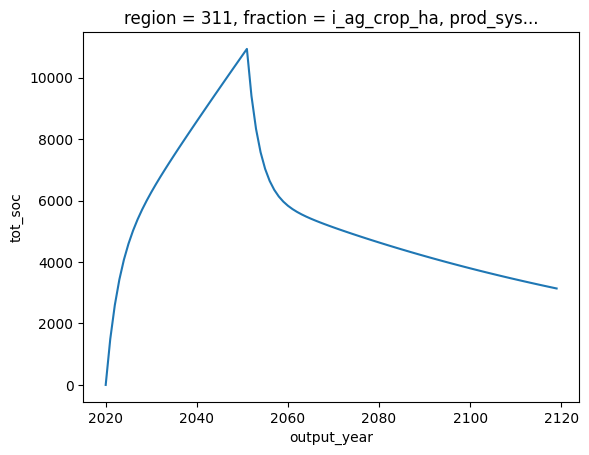

In [25]:
FAI.soc_inventory.tot_soc.sel({'scn': 'fai', 'fraction': 'i_ag_crop_ha', 'prod_system': 'conventional', 'region': 311}).sum('input_year').plot()
#FAI.soc_inventory

In [5]:
FAI.merge_soil_data()

MergeError: conflicting values for variable 'input_area' on objects to be combined. You can skip this check by specifying compat='override'.

## Saving and loading datasets
The `SoilData` class has instance methods to save and read saved datasets to avoid having to rerun the computations between sessions. These are **NOT** automatic, but have to be invoked by the user.

The `save_inventory` and `load_inventory` methods can be called with three optional strings:

- `inputs` saves and loads the input inventory dataset to/from `CIBUSmod/data/soil/temp_results`. The  netcdf file is named `<scenario_name>_input_ds.nc`
- `soc` saves and loads the soc inventory dataset to/from `CIBUSmod/data/soil/temp_results`. The netcdf file is named `<scenario_name>_soc_ds.nc`
- `historic` saves and loads the historic soc inventory dataset to/from `CIBUSmod/data/soil/temp_results`. The netcdf file is named `<scenario_name>_historic_soc_ds.nc`

The `save_instance_state` saves all non dataframe/dataset variables in a pickle file. This needs to be run to include all other set variable states. Without them many methods will not work.  



In [19]:
# The commands in this cell saves the current state of the SoilData instance
FAI.save_inventory()
FAI.save_instance_state()

Dataset set to ['input', 'soc', 'historic']
input_inventory saved as FAI_input_ds.nc in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
input_df saved as FAI_input_df in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
ss_input_df saved as FAI_ss_input_df in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
soc_inventory saved as FAI_soc_ds.nc in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
soc_ha_df saved as FAI_soc_ha_df in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
soc_sko_df saved as FAI_soc_sko_df in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
historic_inventory saved as FAI_historic_ds.nc in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
historic_ha_df saved as FAI_historic_ha_df in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
historic_sko_df saved as FAI_historic_sko_df in /home/niceri/Pythoncode/CIBUSmod/data/soil/temp_results
Saved instance variable states to /home/niceri/Pythoncode/CIBUSmod/data/soil

In [ ]:
# The commands in this cell instantiates and sets all the variable states of the instance to what it was when it was previously saved
FAI = cm.SoilData.load_instance_state('FAI')
FAI.load_inventory()

In [20]:
FAI.check_attributes_status()

NameError: name 'FAI_soil' is not defined

# Code development section below

New code below:

(Data variables:
     input_area  (scn, prod_system, region, input_year, output_year, fraction) float64 74MB ...
     y_pool      (scn, prod_system, region, input_year, output_year, fraction) float64 74MB ...
     o_pool      (scn, prod_system, region, input_year, output_year, fraction) float64 74MB ...
     tot_soc     (scn, prod_system, region, input_year, output_year, fraction) float64 74MB ...
     co2_flux    (scn, prod_system, region, input_year, output_year, fraction) float64 74MB ...,
 Data variables:
     input_area  (prod_system, region, fraction, output_year) float64 2MB 2.79...
     y_pool      (prod_system, region, fraction, output_year) float64 2MB 3.09...
     o_pool      (prod_system, region, fraction, output_year) float64 2MB 1.33...
     tot_soc     (prod_system, region, fraction, output_year) float64 2MB 1.64...
     co2_flux    (prod_system, region, fraction, output_year) float64 2MB nan ...)

NameError: name 'xr' is not defined

In [40]:
from CIBUSmod.soil_modules import soil_utils
import pandas as pd
import numpy as np
allo_dict = soil_utils.alloc_helper(name_df=False,
                                            allo1_df=False,
                                            allo2_df=False,
                                            allo3_df=False,
                                            scenario_dict=False,
                                            verbose=True)
mapper = (allo_dict['crop_andren2004_map'], allo_dict['crop_jacobs_map'], allo_dict['crop_hanna_map'])
sources = ('Andren2004', 'Jacobs2020', 'Hanna')
allo_dfs = (allo_dict['c_allom_andren_df'], allo_dict['c_alloc_jacobs_df'], allo_dict['c_alloc_hanna_df'])

---Executing alloc_helper()---
Warning, first index label is None, conversion of index label not possible
Warning, index label is None. No conversion of index values (should be auto-generated ints)
---Leaving alloc_helper()---


In [28]:
allo_dfs[0]

,straw_a,straw_s,residues_a,residues_s,roots_a,roots_s
crop,,,,,,
fallow,0,0.00,0,0.30,0,0.60
green_fallow,0,0.00,0,0.30,0,0.60
ley,0,0.00,330,0.20,0,0.40
root_crops,0,0.00,0,0.42,0,0.20
seed_ley,2700,0.00,905,0.00,540,0.00
spring_cereals,140,0.83,500,0.15,570,0.20
spring_oilseed,0,1.60,0,1.60,0,0.70
winter_cereals,320,0.62,540,0.40,670,0.06
winter_oilseed,0,0.85,0,0.85,740,0.70


In [26]:
allo_dfs[1]

,i_ag,i_bg
crop,,
asparagus,0.000000,0.044932
beetroot,0.244473,0.055917
broccoli,0.655582,0.722090
carrot,0.136580,0.051069
cauliflower,0.487179,0.649573
celeriac,0.171359,0.372093
cereal_silage-whole_plant,0.049858,0.373219
clover-seeds,8.031746,6.841270
clover-whole_plant,0.250549,0.947253


In [27]:
allo_dfs[2]

,i_ag,i_bg,source
crop,,,
broad_bean_and_lupin,1.325581,0.465116,jensen2010(hi);palouso2015(sr)
common_bean,1.500000,0.500000,bolinder2007(hi);palouso2015(sr)
dry_peas,0.960784,0.392157,jensen2010(hi);palouso2015(sr)
green_peas,0.960784,0.392157,jensen2010(hi);palouso2015(sr)
semi-natural_grasslands,0.666667,0.833333,unkovich2010(hi);hammar2121(sr)


In [7]:
input_df = FAI_new.input_df

In [48]:
df.index.names, df.columns

(FrozenList(['scn', 'crop', 'prod_system', 'region', 'input_year']),
 Index(['area_ha', 'harvest_kgdm', 'crop_residues_harvest_kgdm',
        'manure_cattle_kgC', 'manure_horses_kgC', 'manure_pigs_kgC',
        'manure_poultry_kgC', 'manure_sheep_kgC'],
       dtype='object'))

In [74]:
from typing import Tuple, Optional, Dict, Any
from CIBUSmod.soil_modules import soil_utils
import pandas as pd
import numpy as np
allo_dict = soil_utils.alloc_helper(name_df=False,
                                            allo1_df=False,
                                            allo2_df=False,
                                            allo3_df=False,
                                            scenario_dict=False,
                                            verbose=True)
mapper = (allo_dict['crop_andren2004_map'], allo_dict['crop_jacobs_map'], allo_dict['crop_hanna_map'])
sources = ('Andren2004', 'Jacobs2020', 'Hanna')
allo_dfs = (allo_dict['c_allom_andren_df'], allo_dict['c_alloc_jacobs_df'], allo_dict['c_alloc_hanna_df'])


def calculate_c_inputs_vectorized(input_df1: pd.DataFrame,
                                  mappings: Tuple[Dict[str, Any], ...],
                                  sources: Tuple[str, ...],
                                  c_allo_df: Tuple[pd.DataFrame, ...],
                                  crop_colname: str = 'crop',
                                  colprefix: Optional[Dict[str, str]] = None,
                                  straw_removed: bool = False,
                                  verbose=False) -> pd.DataFrame:
    """
    Vectorized version of calculate_c_inputs function.
    """
    input_df = input_df1.copy()
    if verbose:
        print('---Executing calculate_c_inputs_vectorized()---')
    if colprefix is None:
        colprefix = {'ag': 'i_ag', 'bg': 'i_bg'}

    ag_ha_colname = f"{colprefix['ag']}_{crop_colname}_ha"
    bg_ha_colname = f"{colprefix['bg']}_{crop_colname}_ha"
    alloc_source_colname = f'alloc_source_{crop_colname}'

    # Initialize new columns in the DataFrame
    input_df[ag_ha_colname] = np.nan
    input_df[bg_ha_colname] = np.nan
    input_df[alloc_source_colname] = 'none'
    
    # Build crop-source mapping
    crop_source_mapping = build_crop_source_mapping(c_allo_df)

    # Iterate through each crop in input_df
    for crop in input_df.index.get_level_values('crop').unique():
        source_idx = crop_source_mapping.get(crop, None)
        if source_idx is not None:
            source_df = c_allo_df[source_idx]
            H = input_df.loc[input_df.index.get_level_values(crop_colname) == crop, 'harvest_kgdm']
            
            # Select the calculation method based on source index
            if sources[source_idx] == 'Andren2004':
                ag, bg = allom_asH_vectorized(H, crop, source_df, straw_removed)
            else:  # Assuming Jacobs2020 and Hanna use alloc_input_vectorized
                ag, bg = alloc_input_vectorized(H, crop, source_df, straw_removed)
            
            # Update input_df with the results
            input_df.loc[input_df.index.get_level_values('crop') == crop, ag_ha_colname] = ag
            input_df.loc[input_df.index.get_level_values('crop') == crop, bg_ha_colname] = bg
            input_df.loc[input_df.index.get_level_values('crop') == crop, alloc_source_colname] = sources[source_idx]

    # Assuming 'area_ha' exists in input_df to compute total ag and bg
    ag_tot_colname = f"{colprefix['ag']}_{crop_colname}_kgc"
    bg_tot_colname = f"{colprefix['bg']}_{crop_colname}_kgc"
    input_df[ag_tot_colname] = input_df[ag_ha_colname] * input_df['area_ha']
    input_df[bg_tot_colname] = input_df[bg_ha_colname] * input_df['area_ha']

    if verbose:
        print('---Leaving calculate_c_inputs_vectorized()---')

    return input_df

   

def calculate_c_inputs_vectorized(input_df: pd.DataFrame,
                                  mappings: Tuple[Dict[str, Any], ...],
                                  sources: Tuple[str, ...],
                                  c_allo_df: Tuple[pd.DataFrame, ...],
                                  crop_colname: str = 'crop',
                                  colprefix: Optional[Dict[str, str]] = None,
                                  straw_removed: bool = False,
                                  verbose=False) -> pd.DataFrame:
    """
    Vectorized version of calculate_c_inputs function.
    """
    if verbose:
        print('---Executing calculate_c_inputs_vectorized()---')
    if colprefix is None:
        colprefix = {'ag': 'i_ag', 'bg': 'i_bg'}
        
    idx = input_df.index
    output_df = input_df.reset_index()

    ag_ha_colname = f"{colprefix['ag']}_{crop_colname}_ha"
    bg_ha_colname = f"{colprefix['bg']}_{crop_colname}_ha"
    alloc_source_colname = f'alloc_source_{crop_colname}'

    # Initialize new columns in the DataFrame
    output_df[ag_ha_colname] = np.nan
    output_df[bg_ha_colname] = np.nan
    output_df[alloc_source_colname] = 'none'
    
    # Build crop-source mapping
    crop_source_mapping = build_crop_source_mapping(c_allo_df)

    # Iterate through each crop in input_df
    for crop in output_df['crop'].unique():
        source_idx = crop_source_mapping.get(crop, None)
        if source_idx is not None:
            source_df = c_allo_df[source_idx]
            rows_for_crop = output_df[output_df['crop'] == crop]
            H = rows_for_crop['harvest_kgdm']
            
            # Select the calculation method based on source index
            if sources[source_idx] == 'Andren2004':
                ag, bg = allom_asH_vectorized(H, crop, source_df, straw_removed)
            else:  # Assuming Jacobs2020 and Hanna use alloc_input_vectorized
                ag, bg = alloc_input_vectorized(H, crop, source_df, straw_removed)
            
            # Update input_df with the results
            output_df.loc[input_df['crop'] == crop, ag_ha_colname] = ag
            output_df.loc[input_df['crop'] == crop, bg_ha_colname] = bg
            output_df.loc[input_df['crop'] == crop, alloc_source_colname] = sources[source_idx]

    # Assuming 'area_ha' exists in input_df to compute total ag and bg
    ag_tot_colname = f"{colprefix['ag']}_{crop_colname}_kgc"
    bg_tot_colname = f"{colprefix['bg']}_{crop_colname}_kgc"
    output_df[ag_tot_colname] = output_df[ag_ha_colname] * output_df['area_ha']
    output_df[bg_tot_colname] = output_df[bg_ha_colname] * output_df['area_ha']
    
    output_df = output_df.set_index(idx)

    if verbose:
        print('---Leaving calculate_c_inputs_vectorized()---')

    return output_df

def allom_asH_vectorized(H: pd.Series,
                         crop: str,
                         param_df: pd.DataFrame,
                         straw_removed: bool = False) -> Tuple[pd.Series, pd.Series]:
    """
    Vectorized version to calculate the above and below ground input for multiple crops simultaneously.
    """
    # Ensure H is a Series and param_df is indexed by crop
    if straw_removed:
        i_ag = param_df.loc[crop, 'residues_a'] + param_df.loc[crop, 'residues_s'] * H
    else:
        i_ag_1 = param_df.loc[crop, 'straw_a'] + param_df.loc[crop, 'straw_s'] * H
        i_ag_2 = param_df.loc[crop, 'residues_a'] + param_df.loc[crop, 'residues_s'] * H
        i_ag = i_ag_1 + i_ag_2
    i_bg = param_df.loc[crop, 'roots_a'] + param_df.loc[crop, 'roots_s'] * H
    
    return i_ag, i_bg

def alloc_input_vectorized(H: pd.Series,
                           crop: str,
                           input_df: pd.DataFrame,
                           straw_removed: bool = False) -> Tuple[pd.Series, pd.Series]:
    """
    Vectorized version to calculate the above and below ground input based on allocation factors for multiple crops.
    """
    i_ag = input_df.loc[crop, 'i_ag'] * H
    i_bg = input_df.loc[crop, 'i_bg'] * H
    
    return i_ag, i_bg

def build_crop_source_mapping(allo_dfs):
    crop_source_mapping = {}
    for source_idx, df in enumerate(allo_dfs):
        for crop in df.index:
            # If the crop is not already in the mapping, add it with the current source index
            if crop not in crop_source_mapping:
                crop_source_mapping[crop] = source_idx
    return crop_source_mapping

---Executing alloc_helper()---
Warning, first index label is None, conversion of index label not possible
Warning, index label is None. No conversion of index values (should be auto-generated ints)
---Leaving alloc_helper()---


In [48]:
output_df = calculate_c_inputs_vectorized(input_df,     
                                          mapper,
                                          sources,
                                          allo_dfs,
                                          straw_removed=False,
                                          verbose=False)

In [85]:
output2_df = calculate_c_inputs_vectorized(input_df,     
                                          mapper,
                                          sources,
                                          allo_dfs,
                                          straw_removed=False,
                                          verbose=False)

In [75]:
#import importlib as il
il.reload(soil_utils)
output3_df = soil_utils.calculate_c_inputs(input_df,                              
                                           mapper,
                                           sources,
                                           allo_dfs,
                                           straw_removed=False,
                                           verbose=False)

In [86]:
output_df.equals(output2_df)

True